In [471]:
import h5py as h5 
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import glob
plt.style.use('../../utils/dune.mplstyle')

import sys, os

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

In [472]:
def ticks_to_time(hits_time,tick_time=0.1):
    '''Returns the time in microseconds'''
    return hits_time*tick_time 

In [473]:
test_file = "/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_tests/2x2_AmBe_in_mod2_prompt_window_test_11-19-2025_MOD.FLOW.hdf5"

In [474]:
file = h5.File(test_file, "r")
print(file.keys())

<KeysViewHDF5 ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']>


In [475]:
traj = file["mc_truth/trajectories/data"]
seg = file["mc_truth/segments/data"]

In [476]:
TEST_ENTRY = 4

In [477]:
event_id = TEST_ENTRY + 1

In [478]:
ev_traj= traj[traj['event_id']==event_id]
ev_seg= seg[seg['event_id']==event_id]

In [479]:
print(np.where(seg['event_id']==event_id))
print(ev_seg['pdg_id'])
print(ev_seg['segment_id'])
print(ev_seg['t_start'])

(array([1385, 1386, 1387, 5032, 5033, 5034, 5035, 5036, 5037, 5038, 5039,
       5040, 5041, 5042, 5043, 5044, 5045, 5046, 5047, 5048, 5049, 5050,
       5051, 5052, 5053, 5054, 5055, 5056, 5057, 5058, 5059, 5060, 5061,
       5062, 5063, 5064, 5065, 5066, 5067, 5068, 5069, 5070, 5071, 5072,
       5073, 5074, 5075, 5076, 5077, 5078, 5079, 5080, 5081, 5082, 5884,
       5885, 5886, 5887]),)
[        11 1000180400 1000180400 1000180410         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
   

In [480]:
print(file['mc_truth/interactions'].keys())

<KeysViewHDF5 ['data', 'ref']>


In [481]:
capture_segs_ids = [] 
inelastic_segs_ids = [] 
for this_seg in ev_seg:
    this_seg_anc, this_seg_process = get_ancestry(this_seg['traj_id'],ev_traj)
    if(this_seg_process==1):
        capture_segs_ids.append(this_seg['segment_id'])
    if(this_seg_process==0):
        inelastic_segs_ids.append(this_seg['segment_id'])
    
print("Capture: ",capture_segs_ids)
print("Inelastic: ", inelastic_segs_ids)

Capture:  [4709, 4734, 4735, 4736, 4737, 4738, 4739, 4740, 4741, 4742, 4744, 4745, 4746, 4747, 4748, 4749, 4750, 4751, 4752, 4753, 4754, 4756, 4757, 4758, 4759, 4760, 4761, 4762, 4763, 4765, 4766, 4767, 4768, 4769, 4770, 4771, 4772, 4773, 4775, 4776, 4777, 4778, 4779, 4780, 4781, 4782, 4783, 4784, 4785, 4786, 4787]
Inelastic:  [4697, 4698, 4788, 4693, 4694, 4695, 4696]


In [482]:
for this_seg in ev_seg:
    if(this_seg['segment_id'] not in capture_segs_ids):
        print(this_seg['segment_id'])

4697
4698
4788
4693
4694
4695
4696


In [483]:
entry = event_id-1
prompt_hits_backtrack, prompt_hits = get_charge_event_hits(entry,file)
new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)


In [484]:
new_hits['best_segment_id']

array([4697, 4741, 4741, 4741, 4754, 4752, 4786, 4783, 4761, 4773],
      dtype=int32)

In [485]:
new_hits['neutron_process']

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [486]:
new_hits['parent_neutron_id']

array([0, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [487]:
total = 0
for seg in ev_seg:
    if(seg['segment_id'] in new_hits[new_hits['neutron_process']==1]['best_segment_id']):
        total+=seg['dE']
    else:
        continue
print(total)

3.301330089569092


In [488]:
print(np.sum(new_hits[new_hits['neutron_process']==1]['E']))

3.6211582683746824


In [489]:
hits_x = new_hits['x']
hits_y = new_hits['y']
hits_z = new_hits['z']
hits_t = ticks_to_time(new_hits['ts_pps'])
hits_c = new_hits['neutron_process']


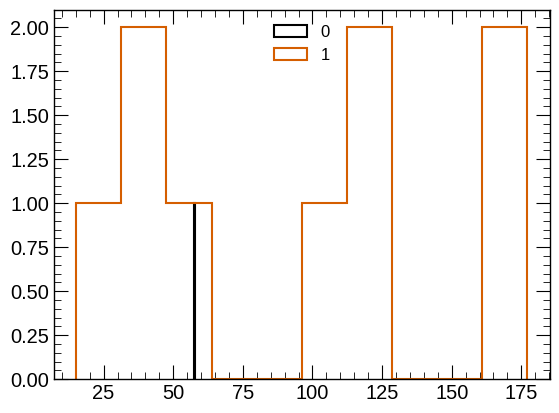

In [490]:
for pr in np.unique(new_hits['neutron_process']):
    label_pr = pr
    plt.hist(ticks_to_time(new_hits[new_hits['neutron_process']==pr]['ts_pps']),histtype='step',label=label_pr)
plt.legend()
plt.show()

In [491]:
my_hits_dset = np.column_stack((hits_x,hits_y,hits_z,hits_c))
print(my_hits_dset)

[[ 12.1377453  -22.39170074 -32.39149857   0.        ]
 [ -8.73730151  -0.9699375   31.75411224   1.        ]
 [ -9.48763417  -0.9699375   31.75411224   1.        ]
 [-12.93597154  -0.9699375   31.75411224   1.        ]
 [-22.24328951   2.1338625   26.71043777   1.        ]
 [-22.24328951   2.52183747  26.71043777   1.        ]
 [-31.21535246  11.83323765  24.77056313   1.        ]
 [-31.07167173  12.22121239  24.77056313   1.        ]
 [ -5.36878677  16.10096169  27.48638725   1.        ]
 [-46.87999444  40.54338837  32.53006363   1.        ]]


In [492]:
event_display(my_hits_dset)

In [493]:
total_capture_dE = []
total_inelastic_dE = []
total_inelastic_hit_E = [] 
total_capture_hit_E = []
nhits_inelastic = []
nhits_capture = [] 

total_capture_seg_dE = []
total_inelastic_seg_dE= [] 

In [494]:
print(np.unique(traj['event_id']))

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163]


In [495]:
def run_charge_readout_checks(base_dir,plots_list="energy"):
    pattern = "2x2_MyQGSP_BERT_ArHP_AmBe_*.FLOW.hdf5"
    search_pattern = os.path.join(base_dir, pattern)
    full_file_list = sorted(glob.glob(search_pattern))

    if not full_file_list:
        print(f"Error: No files found matching: {search_pattern}")
        return

    file_list = []

    for f in full_file_list:
        print("File", f)
        file_list.append(f)
            
    print(f"Found {len(file_list)} file(s):")

    total_capture_dE = []
    total_inelastic_dE = []
    total_inelastic_hit_E = [] 
    total_capture_hit_E = []
    nhits_inelastic = []
    nhits_capture = [] 

    total_capture_seg_dE = []
    total_inelastic_seg_dE= [] 

    for filename in file_list:
        print(filename)
        try:
            with h5.File(filename, "r") as h5_file:
                traj = file["mc_truth/trajectories/data"]
                seg = file["mc_truth/segments/data"]
                for event_id in np.unique(traj['event_id']):
                    my_entry = event_id-1
                    ev_traj= traj[traj['event_id']==event_id]
                    ev_seg= seg[seg['event_id']==event_id]
                    prompt_hits_backtrack, prompt_hits = get_charge_event_hits(my_entry,file)
                    new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)

                    temp_nhits_inelastic = len(new_hits[new_hits['neutron_process']==0])
                    temp_nhits_capture = len(new_hits[new_hits['neutron_process']==1])

                    temp_capture_E = np.sum(new_hits[new_hits['neutron_process']==1]['E'])
                    temp_total  = 0 

                    temp_total_capture_seg_dE = 0
                    temp_total_inelastic_seg_dE = 0


                    for this_seg in ev_seg:
                        this_seg_traj_id = this_seg['traj_id']
                        this_seg_ances, this_seg_process = get_ancestry(this_seg_traj_id,ev_traj)
                        if(this_seg_process == 1): 
                            temp_total_capture_seg_dE+=this_seg['dE']
                        elif(this_seg_process == 0): 
                            temp_total_inelastic_seg_dE+=this_seg['dE']

                    if(temp_total_capture_seg_dE>0.):
                        total_capture_seg_dE.append(temp_total_capture_seg_dE)
                    if(temp_total_inelastic_seg_dE>0.):
                        total_inelastic_seg_dE.append(temp_total_inelastic_seg_dE)






                    if(temp_nhits_inelastic > 0):

                        # I think, when a neutron inelastic scatter, a new trajectory ID is created, need to corroborate this
                        # with a toy simulation

                        new_hits_inelastic = new_hits[new_hits['neutron_process']==0]
                        num_parent_neutrons = np.unique(new_hits_inelastic['parent_neutron_id'])
                        for i_nelastic in num_parent_neutrons:
                            inelastic_E_temp = np.sum(new_hits_inelastic[new_hits_inelastic['parent_neutron_id']==i_nelastic]['E'])        
                            nhits_inelastic.append(len(new_hits_inelastic[new_hits_inelastic['parent_neutron_id']==i_nelastic]))
                            total_inelastic_hit_E.append(inelastic_E_temp)

                            temp_total_E_seg = 0
                            for iseg in ev_seg:
                                if(iseg['segment_id'] in new_hits_inelastic[new_hits_inelastic['parent_neutron_id']==i_nelastic]['best_segment_id']):
                                    temp_total_E_seg+=iseg['dE']
                            total_inelastic_dE.append(temp_total_E_seg)


                    if(temp_nhits_capture > 0): 
                        nhits_capture.append(len(new_hits[new_hits['neutron_process']==1]))
                        total_capture_hit_E.append(temp_capture_E)

                        # Could use array instead of loop here... 
                        for cseg in ev_seg:
                            if(cseg['segment_id'] in new_hits[new_hits['neutron_process']==1]['best_segment_id']):
                                temp_total+=cseg['dE']
                        total_capture_dE.append(temp_total)
                                        
        except Exception as e:
            print(f"Error reading {filename}: {e}")

    
    fig=plt.figure(dpi=200)
    plt.hist(nhits_capture,bins=np.linspace(0.,15.,60),histtype='step',color='blue',label='capture')
    plt.hist(nhits_inelastic,bins=np.linspace(0.,15.,60),histtype='step',color='red',label='inelastic')
    plt.ylabel("Number of entries")
    plt.xlabel("Number of hits")
    plt.legend()
    plt.show()

    fig=plt.figure(dpi=200)
    plt.hist(total_inelastic_hit_E,bins=np.linspace(0,2.,20),histtype='step',color='blue',label='hits')
    plt.hist(total_inelastic_dE, bins=np.linspace(0,2.,20),histtype='step',color='red',label='Backtracked segments')
    plt.ylabel("Number of entries")
    plt.xlabel('Energy [MeV]')
    plt.legend()
    plt.show()

    fig=plt.figure(dpi=200)
    plt.hist(total_capture_hit_E,bins=np.linspace(0,5,40),histtype='step',label='Hits',color='blue')
    plt.hist(total_capture_dE,bins=np.linspace(0,5,40),histtype='step',label='Backtracked segments',color='red')
    plt.ylabel("Number of entries")
    plt.xlabel('Energy MeV')
    plt.legend()
    plt.show()

    fig=plt.figure(dpi=200)
    plt.hist2d(total_capture_dE,total_capture_hit_E,bins=[np.linspace(0,5,20),np.linspace(0,5,20)],cmap='jet')
    plt.plot(np.linspace(0,5.,100),np.linspace(0,5.,100),color='red',ls='--')
    plt.ylabel("Sum of hits E [MeV]")
    plt.xlabel("Sum of backtracked dE [MeV]")
    plt.colorbar()
    plt.show()

    

File /pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764733726_0_TIME_MOD.FLOW.hdf5
File /pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764733726_1_TIME_MOD.FLOW.hdf5
File /pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764735437_2_TIME_MOD.FLOW.hdf5
File /pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764735499_3_TIME_MOD.FLOW.hdf5
File /pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764737207_4_TIME_MOD.FLOW.hdf5
Found 5 file(s):
/pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764733726_0_TIME_MOD.FLOW.hdf5


/pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764733726_1_TIME_MOD.FLOW.hdf5
/pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764735437_2_TIME_MOD.FLOW.hdf5
/pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764735499_3_TIME_MOD.FLOW.hdf5
/pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/2x2_MyQGSP_BERT_ArHP_AmBe_1764737207_4_TIME_MOD.FLOW.hdf5


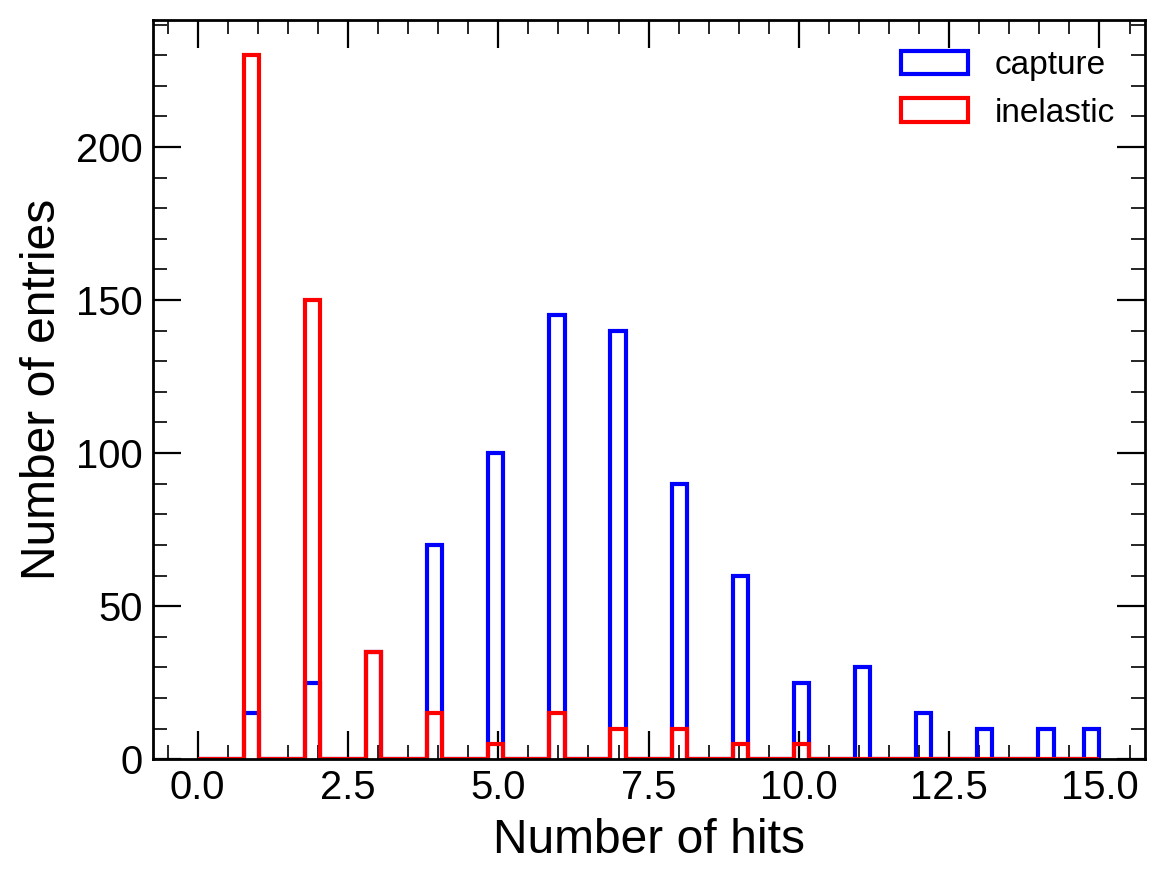

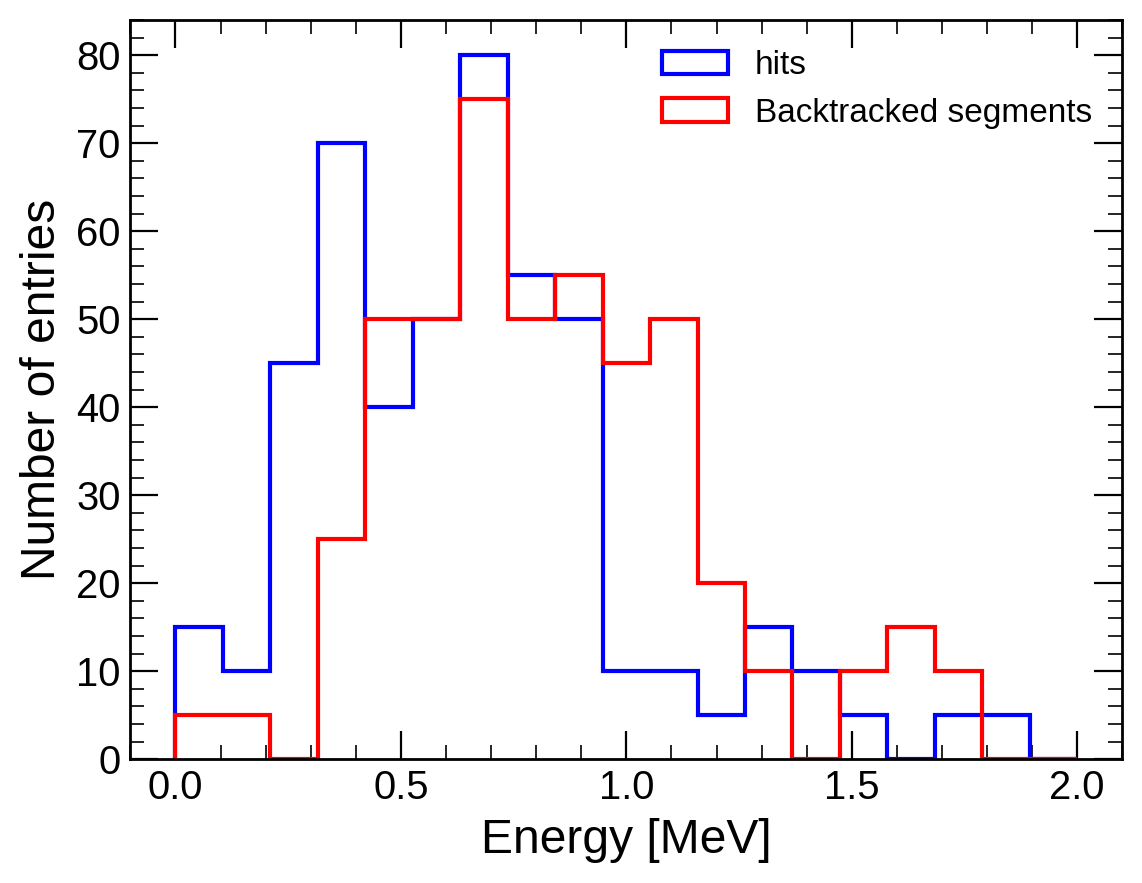

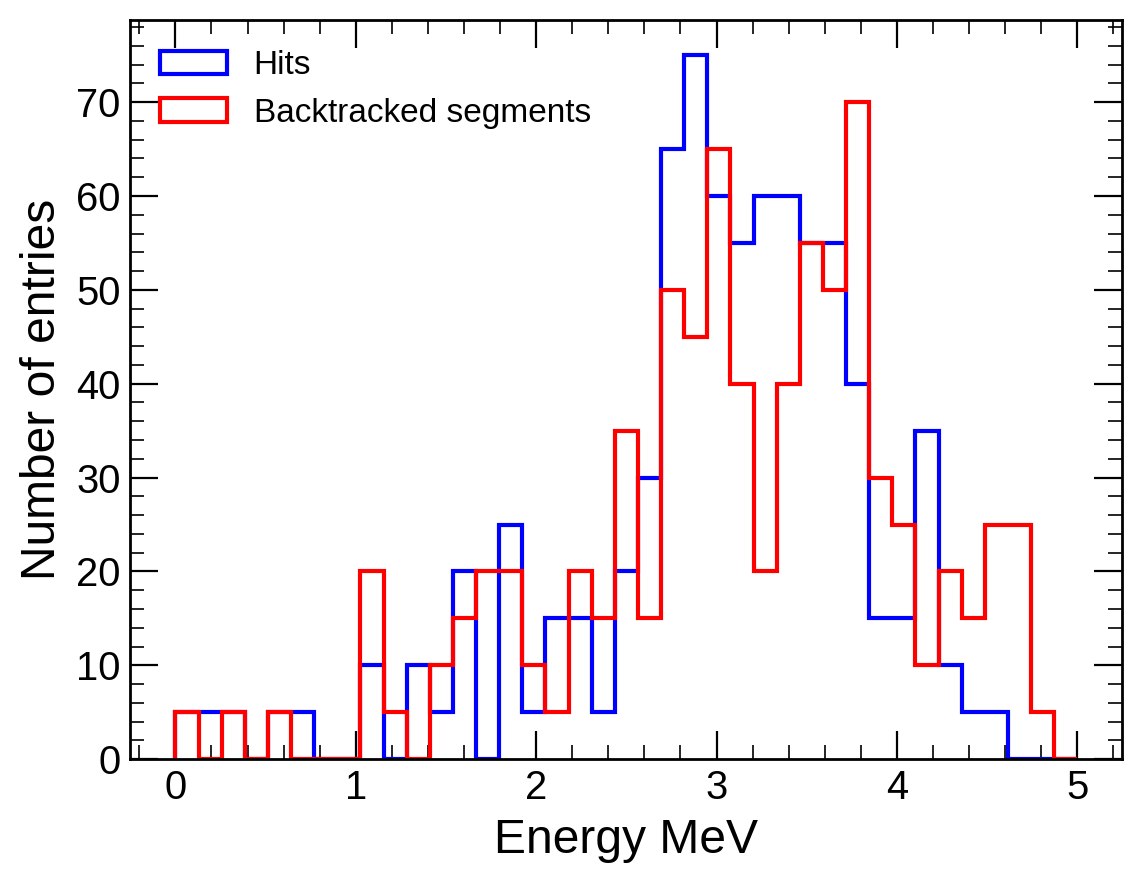

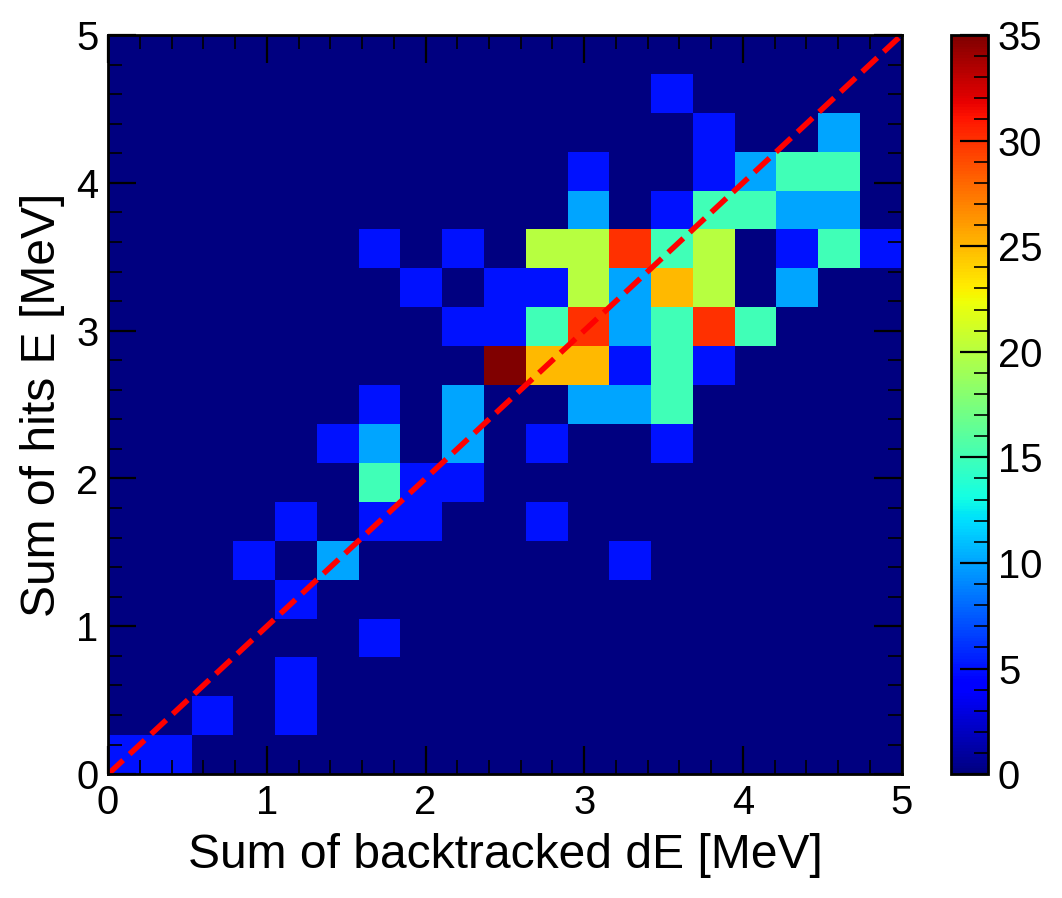

In [496]:
run_charge_readout_checks("/pscratch/sd/l/lmlepin/grid_output/AmBe_prompt_window_test/FLOW/")